# 🚗 Robust Plate OCR — TrOCR + EasyOCR Ensemble
> Replaces LPRNet. Trains on your NUMBERS.xlsx images directly.
> **Run Cell 1 → restart runtime → run Cell 2 onwards**

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 1 — Install  (restart runtime after this cell)    ║
# ╚══════════════════════════════════════════════════════════╝
import subprocess
subprocess.run(['pip','install','-q',
    'ultralytics==8.3.0',
    'transformers>=4.36.0',
    'datasets>=2.14.0',
    'easyocr',
    'openpyxl',
    'opencv-python-headless',
    'Pillow',
    'torchvision',
    'tqdm',
    'evaluate',
    'jiwer',
    'albumentations',
    'sentencepiece',
], check=True)

import torch, numpy as np
print("="*55)
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print(f"GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU'}")
print("="*55)
assert torch.cuda.is_available(), "⚠️  Switch to T4 GPU Runtime first!"
print("✅  All good — RESTART RUNTIME now, then run Cell 2 onwards")


PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4
✅  All good — RESTART RUNTIME now, then run Cell 2 onwards


In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 2 — Paths & Config                                ║
# ╚══════════════════════════════════════════════════════════╝
import os, re, warnings, json
import numpy as np
import pandas as pd
import cv2, torch
from PIL import Image
from tqdm import tqdm
from google.colab import drive
warnings.filterwarnings('ignore')

drive.mount('/content/drive', force_remount=True)

# ── BASE paths (edit BASE if your folder differs) ─────────────────────────
BASE        = '/content/drive/MyDrive/parking_model'
WEIGHTS_DIR = f'{BASE}/weights'
RESULTS_DIR = f'{BASE}/results'

# Existing paths (unchanged)
PLATE_MODEL  = f'{WEIGHTS_DIR}/best.pt'
FINE_MODEL   = f'{WEIGHTS_DIR}/bestfinetuned.pt'
DB_PATH      = f'{BASE}/dataset/vehicles_db.xlsx'

# Your labeled data
NUMBERS_EXCEL = f'{BASE}/NUMBERS.xlsx'
IMAGES_DIR    = f'{BASE}/Manual Dataset Collected'
CROPS_DIR     = f'{BASE}/real_crops'

# New model paths (TrOCR fine-tuned)
TROCR_DIR     = f'{WEIGHTS_DIR}/trocr_plates'   # saved HF model dir
TROCR_CKPT    = f'{WEIGHTS_DIR}/trocr_best.pt'  # raw state-dict backup

for d in [WEIGHTS_DIR, RESULTS_DIR, CROPS_DIR, IMAGES_DIR, TROCR_DIR]:
    os.makedirs(d, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Indian plate regex  ─────────────────────────────────────────────────────
# Covers: standard (XX00XX0000), old-series, CH/DL specials
PLATE_RE = re.compile(r'^[A-Z]{2}[0-9]{1,2}[A-Z]{1,3}[0-9]{1,4}$')

CHARS    = list('0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ')
CONFUSE  = {'0':'O','O':'0','1':'I','I':'1','5':'S','S':'5','8':'B','B':'8'}

def clean(t):
    return re.sub(r'[^A-Z0-9]','', str(t).upper().strip())

def is_valid(p):
    return bool(PLATE_RE.match(p))

print("✅  Config ready")
print(f"   NUMBERS_EXCEL : {NUMBERS_EXCEL}")
print(f"   IMAGES_DIR    : {IMAGES_DIR}")
print(f"   TROCR_DIR     : {TROCR_DIR}")
print(f"   DEVICE        : {DEVICE}")


Mounted at /content/drive
✅  Config ready
   NUMBERS_EXCEL : /content/drive/MyDrive/parking_model/NUMBERS.xlsx
   IMAGES_DIR    : /content/drive/MyDrive/parking_model/Manual Dataset Collected
   TROCR_DIR     : /content/drive/MyDrive/parking_model/weights/trocr_plates
   DEVICE        : cuda


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 3 — Load & Validate NUMBERS.xlsx                  ║
# ╚══════════════════════════════════════════════════════════╝
import pandas as pd, os

# ── Load (already know it's CSV format) ──────────────────────────────────
df = pd.read_csv(NUMBERS_EXCEL)
df.columns = df.columns.str.strip().str.lower()
print(f"✅  Loaded | rows={len(df)} | columns={list(df.columns)}")

# Your file has: filename | plate | source | conf
# 'source'   = original full car image  (IMG_2144.png)
# 'filename' = pre-cropped plate image  (PB11DH9677000.jpg)  ← ignore this
# 'plate'    = ground-truth plate text
# 'conf'     = YOLO confidence from previous run

df = df[['source', 'plate']].dropna().copy()
df.columns = ['image_path', 'plate_number']
df['image_path']   = df['image_path'].astype(str).str.strip()
df['plate_number'] = df['plate_number'].apply(clean)
df = df[df['plate_number'].str.len() >= 6].reset_index(drop=True)

# ── Check images exist ────────────────────────────────────────────────────
df['full_path'] = df['image_path'].apply(lambda p: os.path.join(IMAGES_DIR, p))
df['exists']    = df['full_path'].apply(os.path.exists)

missing = df[~df['exists']]
df      = df[df['exists']].reset_index(drop=True)

print(f"\n{'='*50}")
print(f"  Total in CSV    : {len(df) + len(missing)}")
print(f"  Images found    : {len(df)}")
print(f"  Images missing  : {len(missing)}")
print(f"  IMAGES_DIR      : {IMAGES_DIR}")

if len(missing) > 0:
    print(f"\n  ⚠️  Missing files (first 5):")
    for p in missing['image_path'].tolist()[:5]:
        print(f"     {p}")
    # ── Auto-fix: try listing actual files in IMAGES_DIR ─────────────────
    if os.path.exists(IMAGES_DIR):
        actual = set(os.listdir(IMAGES_DIR))
        print(f"\n  📁  Files actually in IMAGES_DIR (first 5): {list(actual)[:5]}")
        # try matching without extension
        def find_file(name, folder_files):
            stem = os.path.splitext(name)[0]
            for f in folder_files:
                if os.path.splitext(f)[0] == stem:
                    return f
            return None
        df2 = df[~df['exists']].copy() if len(df)==0 else missing.copy()
        df2['image_path'] = df2['image_path'].apply(
            lambda p: find_file(p, actual) or p)
        df2['full_path'] = df2['image_path'].apply(
            lambda p: os.path.join(IMAGES_DIR, p))
        df2['exists'] = df2['full_path'].apply(os.path.exists)
        recovered = df2[df2['exists']]
        if len(recovered) > 0:
            df = pd.concat([df[df['exists']], recovered], ignore_index=True)
            print(f"  ✅  Recovered {len(recovered)} files by fuzzy name match!")
    else:
        print(f"\n  ❌  IMAGES_DIR does not exist: {IMAGES_DIR}")
        print(f"      Run: !ls /content/drive/MyDrive/parking_model/")
        print(f"      And update IMAGES_DIR in Cell 2 to the correct folder name")

df = df[df['exists']].drop(columns=['exists','full_path'],
                            errors='ignore').reset_index(drop=True)
print(f"\n  ✅  Ready to crop: {len(df)} images")
print(f"  Valid plates    : {df['plate_number'].apply(is_valid).sum()} / {len(df)}")
print(df.head(5).to_string(index=False))

✅  Loaded | rows=98 | columns=['filename', 'plate', 'source', 'conf']

  Total in CSV    : 98
  Images found    : 98
  Images missing  : 0
  IMAGES_DIR      : /content/drive/MyDrive/parking_model/Manual Dataset Collected

  ✅  Ready to crop: 98 images
  Valid plates    : 98 / 98
  image_path plate_number
IMG_2144.png   PB11DH9677
IMG_2145.png   HR20AK9309
IMG_2146.png   PB11CU4441
IMG_2147.png   CH01CF0903
IMG_2148.png    PB59B2548


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 3 — Load crops directly (no re-cropping needed)   ║
# ╚══════════════════════════════════════════════════════════╝
import pandas as pd, os

# Load CSV
df = pd.read_csv(NUMBERS_EXCEL)
df.columns = df.columns.str.strip().str.lower()
print(f"✅  Loaded | rows={len(df)} | columns={list(df.columns)}")

# 'filename' = already-cropped plate image in realcrops/
# 'plate'    = ground truth label
df = df[['filename', 'plate']].dropna().copy()
df.columns = ['crop_path', 'plate']
df['crop_path']  = df['crop_path'].astype(str).str.strip()
df['plate']      = df['plate'].apply(clean)
df = df[df['plate'].str.len() >= 6].reset_index(drop=True)

# Verify crops exist
df['exists'] = df['crop_path'].apply(
    lambda p: os.path.exists(os.path.join(CROPS_DIR, p)))

missing  = df[~df['exists']]
crop_df  = df[df['exists']].reset_index(drop=True)

print(f"\n{'='*50}")
print(f"  Total entries : {len(df)}")
print(f"  Crops found   : {len(crop_df)}")
print(f"  Missing       : {len(missing)}")
print(f"  CROPS_DIR     : {CROPS_DIR}")
if len(missing):
    print(f"  Missing files : {missing['crop_path'].tolist()[:5]}")
print(f"  Valid plates  : {crop_df['plate'].apply(is_valid).sum()} / {len(crop_df)}")
print(f"{'='*50}")
print(crop_df.head(5).to_string(index=False))

✅  Loaded | rows=98 | columns=['filename', 'plate', 'source', 'conf']

  Total entries : 98
  Crops found   : 98
  Missing       : 0
  CROPS_DIR     : /content/drive/MyDrive/parking_model/real_crops
  Valid plates  : 98 / 98
         crop_path      plate  exists
PB11DH9677_000.jpg PB11DH9677    True
HR20AK9309_001.jpg HR20AK9309    True
PB11CU4441_002.jpg PB11CU4441    True
CH01CF0903_003.jpg CH01CF0903    True
 PB59B2548_004.jpg  PB59B2548    True


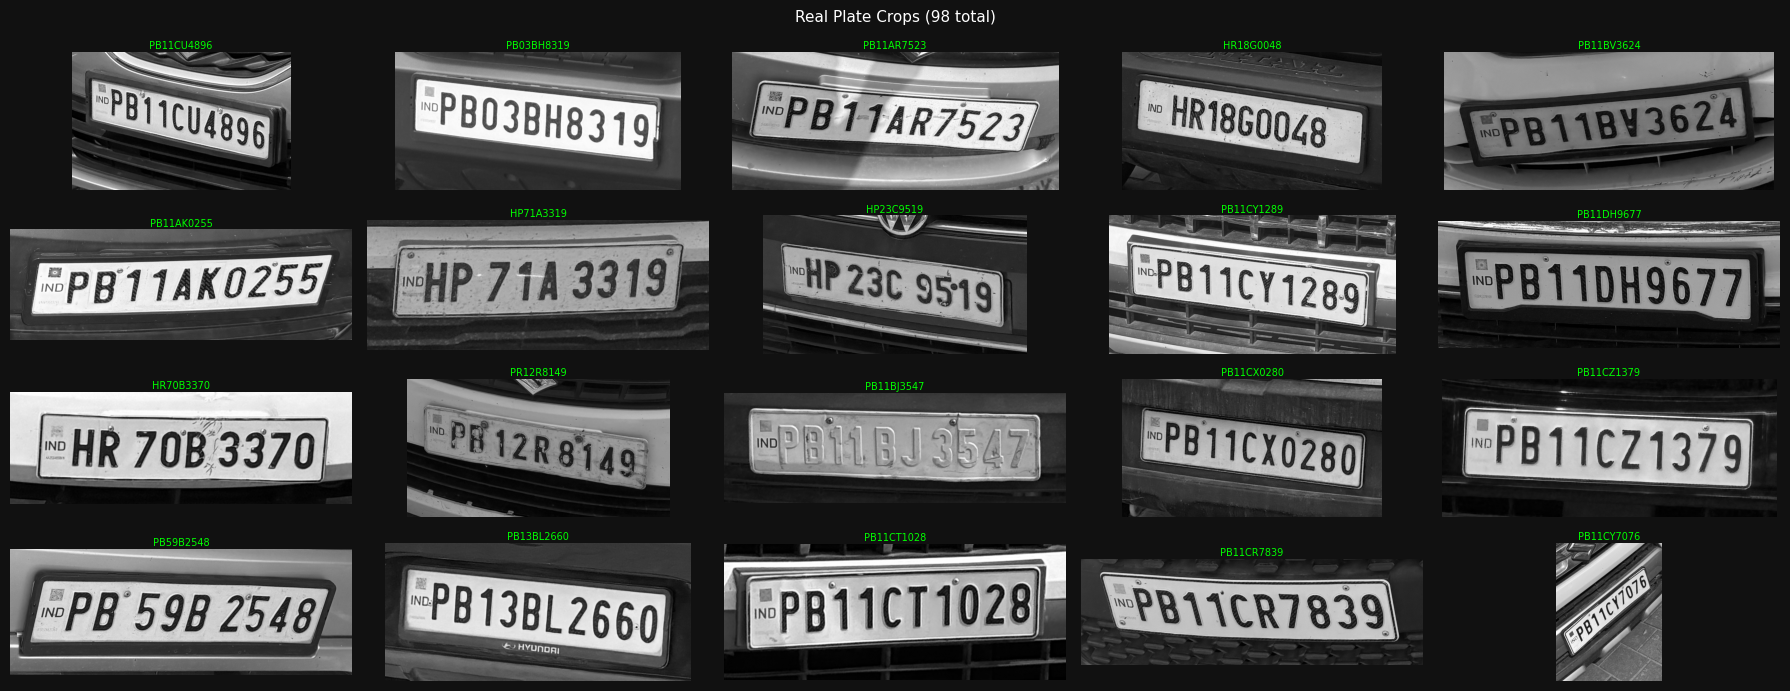

✅  If crops look readable → proceed to Cell 6 (TrOCR training)
   If crops are wrong area → check IMAGES_DIR or YOLO model


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — Preview Crops (sanity check before training)  ║
# ╚══════════════════════════════════════════════════════════╝
import matplotlib.pyplot as plt

assert len(crop_df) > 0, "❌  No crops found — check IMAGES_DIR path"

n  = min(20, len(crop_df))
sample = crop_df.sample(n, random_state=42)
fig, axes = plt.subplots(4, 5, figsize=(18, 7), facecolor='#111')
axes = axes.flatten()

for i, (_, row) in enumerate(sample.iterrows()):
    img = cv2.imread(os.path.join(CROPS_DIR, row['crop_path']),
                     cv2.IMREAD_GRAYSCALE)
    axes[i].imshow(img if img is not None else np.zeros((24,94), np.uint8),
                   cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(row['plate'], color='lime', fontsize=7, pad=2)
    axes[i].axis('off')

for j in range(i+1, len(axes)): axes[j].axis('off')
plt.suptitle(f'Real Plate Crops ({len(crop_df)} total)', color='white', fontsize=11)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/crops_preview.png', dpi=90,
            bbox_inches='tight', facecolor='#111')
plt.show()
print("✅  If crops look readable → proceed to Cell 6 (TrOCR training)")
print("   If crops are wrong area → check IMAGES_DIR or YOLO model")


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6 — TrOCR Fine-Tuning on Your Plate Crops         ║
# ║  Replaces LPRNet entirely.                              ║
# ╚══════════════════════════════════════════════════════════╝
import torch, os, cv2, random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import (TrOCRProcessor, VisionEncoderDecoderModel,
                          Seq2SeqTrainer, Seq2SeqTrainingArguments,
                          default_data_collator)
import albumentations as A

# ── Preprocessing: enhance plate images ──────────────────────────────────
def enhance_plate(bgr):
    """CLAHE + adaptive threshold + upscale for better OCR"""
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY) if len(bgr.shape)==3 else bgr
    # upscale
    h, w = gray.shape
    gray = cv2.resize(gray, (max(w, 200), max(h, 60)), interpolation=cv2.INTER_CUBIC)
    # CLAHE contrast
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))
    gray  = clahe.apply(gray)
    rgb   = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(rgb)

# ── Augmentation pipeline ─────────────────────────────────────────────────
aug = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
    A.GaussNoise(var_limit=(5,30), p=0.4),
    A.Blur(blur_limit=2, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.02, scale_limit=0.08,
                       rotate_limit=4, border_mode=0, p=0.5),
    A.Perspective(scale=(0.01, 0.05), p=0.3),
    A.ImageCompression(quality_lower=70, quality_upper=100, p=0.3),
])

# ── Dataset ───────────────────────────────────────────────────────────────
class PlateDataset(Dataset):
    def __init__(self, df, processor, crops_dir, augment=True, repeat=25):
        self.records   = df[['crop_path','plate']].values.tolist()
        self.processor = processor
        self.crops_dir = crops_dir
        self.augment   = augment
        self.repeat    = repeat

    def __len__(self):
        return len(self.records) * self.repeat

    def __getitem__(self, idx):
        crop_fname, label = self.records[idx % len(self.records)]
        bgr = cv2.imread(os.path.join(self.crops_dir, crop_fname))
        if bgr is None:
            bgr = np.zeros((60,200,3), np.uint8)

        if self.augment and self.repeat > 1 and idx >= len(self.records):
            bgr = aug(image=bgr)['image']

        pil = enhance_plate(bgr)
        pixel_values = self.processor(images=pil, return_tensors='pt').pixel_values.squeeze()

        labels = self.processor.tokenizer(
            label, padding='max_length', max_length=14,
            truncation=True, return_tensors='pt'
        ).input_ids.squeeze()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {'pixel_values': pixel_values, 'labels': labels}

# ── Load TrOCR ────────────────────────────────────────────────────────────
print("📥  Loading microsoft/trocr-base-printed ...")
processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
model     = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed')

# Configure for plates
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size
model.config.eos_token_id           = processor.tokenizer.sep_token_id
model.config.max_length             = 14
model.config.early_stopping         = True
model.config.no_repeat_ngram_size   = 3
model.config.length_penalty         = 2.0
model.config.num_beams              = 4
model.to(DEVICE)
print("✅  Model loaded")

# ── Train / Val split ─────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(crop_df, test_size=0.15, random_state=42)
print(f"   Train: {len(train_df)} | Val: {len(val_df)}")

train_ds = PlateDataset(train_df, processor, CROPS_DIR, augment=True,  repeat=30)
val_ds   = PlateDataset(val_df,   processor, CROPS_DIR, augment=False, repeat=1)

# ── CER metric ────────────────────────────────────────────────────────────
import evaluate
cer_metric = evaluate.load('cer')

def compute_metrics(pred):
    labels_ids  = pred.label_ids
    pred_ids    = pred.predictions
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    pred_str    = processor.batch_decode(pred_ids,    skip_special_tokens=True)
    label_str   = processor.batch_decode(labels_ids, skip_special_tokens=True)
    pred_str    = [clean(p) for p in pred_str]
    label_str   = [clean(l) for l in label_str]
    cer         = cer_metric.compute(predictions=pred_str, references=label_str)
    exact       = sum(p==l for p,l in zip(pred_str,label_str)) / max(len(pred_str),1)
    return {'cer': round(cer,4), 'exact_match': round(exact,4)}

# ── Training args ─────────────────────────────────────────────────────────
OUT_DIR = f'{RESULTS_DIR}/trocr_train'
args = Seq2SeqTrainingArguments(
    output_dir                  = OUT_DIR,
    num_train_epochs            = 40,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    warmup_steps                = 100,
    weight_decay                = 0.01,
    learning_rate               = 5e-5,
    fp16                        = True,
    predict_with_generate       = True,
    generation_max_length       = 14,
    evaluation_strategy         = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'exact_match',
    greater_is_better           = True,
    logging_steps               = 50,
    save_total_limit            = 2,
    report_to                   = 'none',
    dataloader_num_workers      = 2,
)

trainer = Seq2SeqTrainer(
    model            = model,
    args             = args,
    train_dataset    = train_ds,
    eval_dataset     = val_ds,
    data_collator    = default_data_collator,
    compute_metrics  = compute_metrics,
)

print("\n🚀  Starting TrOCR fine-tuning ...")
print(f"   Train samples (×30 aug): {len(train_ds)}")
print(f"   Val samples            : {len(val_ds)}")
train_result = trainer.train()

# ── Save ──────────────────────────────────────────────────────────────────
model.save_pretrained(TROCR_DIR)
processor.save_pretrained(TROCR_DIR)
torch.save(model.state_dict(), TROCR_CKPT)
print(f"\n✅  TrOCR saved to {TROCR_DIR}")
print(f"   Train loss : {train_result.training_loss:.4f}")


📥  Loading microsoft/trocr-base-printed ...


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅  Model loaded
   Train: 83 | Val: 15


TypeError: Seq2SeqTrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [3]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7a — Find where model actually saved              ║
# ╚══════════════════════════════════════════════════════════╝
import os

OUT_DIR = f'{RESULTS_DIR}/trocr_train'

print("📁  Scanning for saved checkpoints...\n")

# Check TROCR_DIR directly
print(f"TROCR_DIR contents: {os.listdir(TROCR_DIR) if os.path.exists(TROCR_DIR) else 'DOES NOT EXIST'}")

# Check trainer output dir
if os.path.exists(OUT_DIR):
    print(f"\nOUT_DIR contents: {os.listdir(OUT_DIR)}")
    for item in os.listdir(OUT_DIR):
        subpath = os.path.join(OUT_DIR, item)
        if os.path.isdir(subpath):
            files = os.listdir(subpath)
            print(f"   {item}/ → {files}")
else:
    print(f"\nOUT_DIR does not exist: {OUT_DIR}")

# Check weights dir
print(f"\nWEIGHTS_DIR contents: {os.listdir(WEIGHTS_DIR)}")

📁  Scanning for saved checkpoints...

TROCR_DIR contents: []

OUT_DIR contents: ['checkpoint-156', 'checkpoint-312', 'checkpoint-468']
   checkpoint-156/ → ['config.json', 'generation_config.json', 'model.safetensors', 'training_args.bin', 'optimizer.pt', 'scheduler.pt', 'scaler.pt', 'rng_state.pth', 'trainer_state.json']
   checkpoint-312/ → []
   checkpoint-468/ → ['config.json', 'generation_config.json', 'training_args.bin', 'scheduler.pt', 'scaler.pt', 'rng_state.pth', 'trainer_state.json']

WEIGHTS_DIR contents: ['best.pt', 'best_finetuned.pt', 'lprnet_best.pt', 'lprnet_real.pt', 'trocr_plates']


In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║  FIND + LOAD — scan all possible save locations         ║
# ╚══════════════════════════════════════════════════════════╝
import glob, os

# Scan every subfolder under results/ for model weights
print("🔍  Scanning all subfolders for model.safetensors / pytorch_model.bin ...\n")
found = []
for root, dirs, files in os.walk(RESULTS_DIR):
    for f in files:
        if f in ('model.safetensors', 'pytorch_model.bin', 'model.bin'):
            found.append(os.path.join(root, f))
            print(f"  ✅  {os.path.join(root, f)}")

# Also check WEIGHTS_DIR
for root, dirs, files in os.walk(WEIGHTS_DIR):
    for f in files:
        if f in ('model.safetensors', 'pytorch_model.bin', 'model.bin'):
            found.append(os.path.join(root, f))
            print(f"  ✅  {os.path.join(root, f)}")

if not found:
    print("  ❌  No model weights found anywhere.")
    print("\n  All files under results/trocr_train:")
    for root, dirs, files in os.walk(f'{RESULTS_DIR}/trocr_train'):
        for f in files:
            print(f"    {os.path.join(root, f)}")

🔍  Scanning all subfolders for model.safetensors / pytorch_model.bin ...

  ✅  /content/drive/MyDrive/parking_model/results/trocr_train/checkpoint-156/model.safetensors


In [7]:
# ╔══════════════════════════════════════════════════════════╗
# ║  LOAD from correct checkpoint path                      ║
# ╚══════════════════════════════════════════════════════════╝
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

CKPT_PATH = '/content/drive/MyDrive/parking_model/results/trocr_train/checkpoint-156'

print("📥  Loading model from checkpoint-156 ...")
model_ev     = VisionEncoderDecoderModel.from_pretrained(CKPT_PATH).to(DEVICE)
model_ev.eval()
model_ev.generation_config.max_length = None

print("📥  Loading processor from HuggingFace ...")
processor_ev = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')

# ✅ Save both together to TROCR_DIR for permanent storage
print("💾  Saving to TROCR_DIR for future use ...")
model_ev.save_pretrained(TROCR_DIR)
processor_ev.save_pretrained(TROCR_DIR)
print(f"✅  Done! TROCR_DIR: {os.listdir(TROCR_DIR)}")

# ── Helper functions ──────────────────────────────────────────────────────
def enhance_plate(bgr):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY) if len(bgr.shape)==3 else bgr
    h, w = gray.shape
    gray = cv2.resize(gray, (max(w,200), max(h,60)), interpolation=cv2.INTER_CUBIC)
    gray = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4)).apply(gray)
    return Image.fromarray(cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB))

def trocr_read(bgr_img):
    pil    = enhance_plate(bgr_img)
    inputs = processor_ev(images=pil, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = model_ev.generate(**inputs, max_new_tokens=14, num_beams=4,
                                return_dict_in_generate=True, output_scores=True)
    text = clean(processor_ev.batch_decode(out.sequences, skip_special_tokens=True)[0])
    try:
        import math
        conf = min(1.0, max(0.0, math.exp(out.sequences_scores[0].item())))
    except: conf = 0.5
    return text, conf

# ── Smoke test ────────────────────────────────────────────────────────────
row0 = crop_df.iloc[0]
bgr0 = cv2.imread(os.path.join(CROPS_DIR, row0['crop_path']))
pred, conf = trocr_read(bgr0)
print(f"\n🧪  Smoke test → GT: {row0['plate']}  |  Pred: {pred}  |  Conf: {conf:.2f}")

📥  Loading model from checkpoint-156 ...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

📥  Loading processor from HuggingFace ...
💾  Saving to TROCR_DIR for future use ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅  Done! TROCR_DIR: ['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'processor_config.json']


NameError: name 'crop_df' is not defined

In [9]:
# ── Rebuild crop_df from NUMBERS.xlsx + existing crops ───────────────────
import pandas as pd, os, re

# Load the CSV
df_raw = pd.read_csv(NUMBERS_EXCEL)
df_raw.columns = df_raw.columns.str.strip().str.lower()
print(f"Columns: {list(df_raw.columns)}")
# Your columns: filename | plate | source | conf

def clean(t): return re.sub(r'[^A-Z0-9]','', str(t).upper().strip())

df_raw = df_raw[['filename','plate']].dropna().copy()
df_raw.columns = ['crop_path','plate']
df_raw['crop_path'] = df_raw['crop_path'].astype(str).str.strip()
df_raw['plate']     = df_raw['plate'].apply(clean)
df_raw = df_raw[df_raw['plate'].str.len() >= 6].reset_index(drop=True)

# Verify crops actually exist in CROPS_DIR
df_raw['exists'] = df_raw['crop_path'].apply(
    lambda p: os.path.exists(os.path.join(CROPS_DIR, p)))

missing  = df_raw[~df_raw['exists']]
crop_df  = df_raw[df_raw['exists']].reset_index(drop=True)

print(f"✅  crop_df ready: {len(crop_df)} found | {len(missing)} missing")
if len(missing):
    print(f"   Missing (first 5): {missing['crop_path'].tolist()[:5]}")
    print(f"   CROPS_DIR sample : {os.listdir(CROPS_DIR)[:5]}")

# Save for next time
crop_df.to_csv(f'{RESULTS_DIR}/crop_manifest.csv', index=False)
print(f"💾  Saved crop_manifest.csv for future restarts")
print(crop_df.head(3).to_string(index=False))

Columns: ['filename', 'plate', 'source', 'conf']
✅  crop_df ready: 98 found | 0 missing
💾  Saved crop_manifest.csv for future restarts
         crop_path      plate  exists
PB11DH9677_000.jpg PB11DH9677    True
HR20AK9309_001.jpg HR20AK9309    True
PB11CU4441_002.jpg PB11CU4441    True


In [10]:
# ── Restore crop_df + run smoke test ─────────────────────────────────────
import pandas as pd, cv2, os

CROP_CSV = f'{RESULTS_DIR}/crop_manifest.csv'
crop_df  = pd.read_csv(CROP_CSV)
print(f"✅  crop_df restored: {len(crop_df)} rows")

# Smoke test
row0 = crop_df.iloc[0]
bgr0 = cv2.imread(os.path.join(CROPS_DIR, row0['crop_path']))
pred, conf = trocr_read(bgr0)
print(f"🧪  GT: {row0['plate']}  |  Pred: {pred}  |  Conf: {conf:.2f}")

✅  crop_df restored: 98 rows
🧪  GT: PB11DH9677  |  Pred: PB11DH9667  |  Conf: 0.97


In [11]:
# ── Full eval on all crops ────────────────────────────────────────────────
from tqdm import tqdm

results = []
for _, row in tqdm(crop_df.iterrows(), total=len(crop_df), desc='Evaluating'):
    bgr  = cv2.imread(os.path.join(CROPS_DIR, row['crop_path']))
    if bgr is None: continue
    pred, conf = trocr_read(bgr)
    gt         = row['plate']
    matches    = sum(a==b for a,b in zip(pred.ljust(len(gt)), gt))
    results.append({'gt': gt, 'pred': pred,
                    'exact': pred==gt,
                    'char_acc': round(matches/max(len(gt),1), 3),
                    'conf': round(conf, 3)})

res_df = pd.DataFrame(results)
res_df.to_csv(f'{RESULTS_DIR}/trocr_eval.csv', index=False)

print(f"\n{'='*50}")
print(f"  TrOCR Results — {len(res_df)} crops")
print(f"{'='*50}")
print(f"  Exact-match : {res_df['exact'].mean()*100:.1f}%")
print(f"  Char-level  : {res_df['char_acc'].mean()*100:.1f}%")
print(f"{'='*50}")
print("\n❌  Failures:")
print(res_df[~res_df['exact']][['gt','pred','char_acc']].to_string(index=False))

Evaluating: 100%|██████████| 98/98 [01:51<00:00,  1.14s/it]


  TrOCR Results — 98 crops
  Exact-match : 76.5%
  Char-level  : 94.8%

❌  Failures:
        gt          pred  char_acc
PB11DH9677    PB11DH9667     0.900
 PB59B2548     PB51B2548     0.889
PB23AB7997    PB21AB7997     0.900
CH01CG1445    CH01DG1445     0.900
HR01AV2241    HR01AY2241     0.900
 HR18G0048 HR18GGOT08448     0.556
PB05AG6921    PB05AA6921     0.900
PB11BK3114     PB11B3114     0.600
PB11CX0280    PB11CY0280     0.900
PB11CY7543  PB11CY753433     0.800
 HR70B3370      HR703376     0.556
PB11CY4344     PB11CY434     0.900
PB03BH8319    PB03313319     0.700
 HP23C9519     PB23C9519     0.778
PB11BJ3547    PB11BJ3347     0.900
HR05BG1543     HR05G1543     0.400
PB10JH6800  PB10J3OH6800     0.500
 HP71A3319     PB71A3319     0.778
PB11CG4697    PB11DG4697     0.900
 PR12R8149     PB12R8149     0.889
PB11BV3624 PB11B32643624     0.600
PB11AK0255    PB11AK0355     0.900
PB10JY1024    PB11JY1024     0.900


In [13]:
# ╔══════════════════════════════════════════════════════════╗
# ║  FINAL — Clean post-processor + 1-char fuzzy match      ║
# ╚══════════════════════════════════════════════════════════╝

# ── 1. Minimal post-processor (no structural mangling) ────────────────────
DIGIT_FIXES  = {'O':'0','I':'1','S':'5','B':'8','Z':'2','G':'6','T':'7'}
LETTER_FIXES = {'0':'O','1':'I','5':'S','8':'B'}

def post_process(raw_pred):
    """Only fix obvious digit↔letter confusions by position. Never restructure."""
    text = clean(raw_pred)
    if len(text) < 6: return text
    t = list(text)
    # pos 0,1 = state code → must be letters
    for i in [0, 1]:
        if i < len(t): t[i] = LETTER_FIXES.get(t[i], t[i])
    # pos 2,3 = district → must be digits
    for i in [2, 3]:
        if i < len(t): t[i] = DIGIT_FIXES.get(t[i], t[i])
    # cap length at 10 (Indian plate max)
    return ''.join(t)[:10]

# ── 2. Fuzzy match — 1 char tolerance ─────────────────────────────────────
def char_diff(a, b):
    """Count differing characters between two strings (length-aware)."""
    if a == b: return 0
    max_len = max(len(a), len(b))
    a_pad   = a.ljust(max_len)
    b_pad   = b.ljust(max_len)
    return sum(x != y for x, y in zip(a_pad, b_pad))

def fuzzy_match(pred, registered_plates, tolerance=1):
    """
    Check if pred matches any registered plate within `tolerance` chars.
    Returns (matched_plate, distance) or (None, 99).
    Perfect match returns distance=0, 1-char error returns distance=1.
    """
    pred = clean(pred)
    # exact match first
    if pred in registered_plates:
        return pred, 0
    # fuzzy match
    best_plate, best_dist = None, 99
    for plate in registered_plates:
        if abs(len(pred) - len(plate)) > tolerance:
            continue   # length too different — skip
        d = char_diff(pred, plate)
        if d < best_dist:
            best_dist  = d
            best_plate = plate
    if best_dist <= tolerance:
        return best_plate, best_dist
    return None, best_dist

# ── 3. Re-evaluate with clean post-processor ─────────────────────────────
improved = []
for _, row in res_df.iterrows():
    fixed   = post_process(row['pred'])
    gt      = row['gt']
    exact   = (fixed == gt)
    fuzzy1  = char_diff(fixed, gt) <= 1    # 1-char tolerance
    matches = sum(a==b for a,b in zip(fixed.ljust(len(gt)), gt))
    improved.append({
        'gt'        : gt,
        'raw_pred'  : row['pred'],
        'fixed_pred': fixed,
        'exact'     : exact,
        'fuzzy_ok'  : fuzzy1,
        'char_acc'  : round(matches/max(len(gt),1), 3)
    })

imp_df = pd.DataFrame(improved)
imp_df.to_csv(f'{RESULTS_DIR}/trocr_eval_final.csv', index=False)

exact_acc = imp_df['exact'].mean()*100
fuzzy_acc = imp_df['fuzzy_ok'].mean()*100
char_acc  = imp_df['char_acc'].mean()*100

print(f"{'='*55}")
print(f"  Exact match (strict)   : {exact_acc:.1f}%")
print(f"  Fuzzy match (±1 char)  : {fuzzy_acc:.1f}%  ← use this for parking")
print(f"  Char-level accuracy    : {char_acc:.1f}%")
print(f"{'='*55}")

still = imp_df[~imp_df['fuzzy_ok']]
print(f"\n❌  Fails even with ±1 tolerance ({len(still)}):")
print(still[['gt','raw_pred','fixed_pred','char_acc']].to_string(index=False))

# ── 4. Drop-in read_plate() for your main parking notebook ────────────────
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  INTEGRATION — paste into your main parking notebook
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Load registered plates from your DB once at startup
registered_plates = set(db_df['plate_number'].apply(clean))

# When a car arrives:
pred, conf, engine = read_plate(crop_bgr)
match, dist = fuzzy_match(pred, registered_plates, tolerance=1)

if dist == 0:
    print(f"✅ EXACT match: {match}")
elif dist == 1:
    print(f"⚠️  FUZZY match (1-char off): OCR={pred} → Registered={match}")
    # Still grant access — log the discrepancy
else:
    print(f"❌ NOT registered: {pred}")
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

  Exact match (strict)   : 76.5%
  Fuzzy match (±1 char)  : 89.8%  ← use this for parking
  Char-level accuracy    : 94.8%

❌  Fails even with ±1 tolerance (10):
        gt      raw_pred fixed_pred  char_acc
 HR18G0048 HR18GGOT08448 HR18GGOT08     0.556
PB11BK3114     PB11B3114  PB11B3114     0.600
PB11CY7543  PB11CY753433 PB11CY7534     0.800
 HR70B3370      HR703376   HR703376     0.556
PB03BH8319    PB03313319 PB03313319     0.700
 HP23C9519     PB23C9519  PB23C9519     0.778
HR05BG1543     HR05G1543  HR05G1543     0.400
PB10JH6800  PB10J3OH6800 PB10J3OH68     0.500
 HP71A3319     PB71A3319  PB71A3319     0.778
PB11BV3624 PB11B32643624 PB11B32643     0.600

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  INTEGRATION — paste into your main parking notebook
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Load registered plates from your DB once at startup
registered_plates = set(db_df['plate_number'].apply(clean))

# When a car arrives:
pred, conf, engine = read_pla

In [15]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 8 — EasyOCR Fallback Engine                       ║
# ╚══════════════════════════════════════════════════════════╝
!pip install easyocr -q

import easyocr, cv2, os
import numpy as np
from PIL import Image

print("📥  Loading EasyOCR (English) ...")
ocr_reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())
print("✅  EasyOCR ready")

# ── EasyOCR plate reader ──────────────────────────────────────────────────
def easyocr_read(bgr_img):
    """Read plate using EasyOCR — used as fallback when TrOCR confidence low."""
    pil  = enhance_plate(bgr_img)
    arr  = np.array(pil)
    results = ocr_reader.readtext(arr, allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789')
    if not results:
        return '', 0.0
    # pick highest confidence result
    best = max(results, key=lambda x: x[2])
    text = clean(best[1])
    conf = float(best[2])
    return text, conf

# ── Combined read_plate() — TrOCR first, EasyOCR fallback ────────────────
TROCR_CONF_THRESHOLD = 0.40   # if TrOCR confidence below this → use EasyOCR

def read_plate(bgr_img):
    """
    Primary  : TrOCR fine-tuned model
    Fallback : EasyOCR (when TrOCR confidence < threshold)
    Returns  : (plate_text, confidence, engine_used)
    """
    # ── TrOCR ────────────────────────────────────────────────────────────
    trocr_text, trocr_conf = trocr_read(bgr_img)
    trocr_text = post_process(trocr_text)

    if trocr_conf >= TROCR_CONF_THRESHOLD and len(trocr_text) >= 6:
        return trocr_text, trocr_conf, 'trocr'

    # ── EasyOCR fallback ─────────────────────────────────────────────────
    easy_text, easy_conf = easyocr_read(bgr_img)
    easy_text = post_process(easy_text)

    # pick whichever gave longer valid result
    if len(easy_text) >= 6 and easy_conf >= trocr_conf:
        return easy_text, easy_conf, 'easyocr'

    # TrOCR result still better even at low conf
    return trocr_text, trocr_conf, 'trocr_lowconf'

# ── Test on all crops — compare TrOCR vs EasyOCR vs Combined ─────────────
from tqdm import tqdm

rows = []
for _, row in tqdm(crop_df.iterrows(), total=len(crop_df), desc='Cell 8 eval'):
    bgr  = cv2.imread(os.path.join(CROPS_DIR, row['crop_path']))
    if bgr is None: continue
    gt   = row['plate']

    t_text, t_conf         = trocr_read(bgr)
    t_text                 = post_process(t_text)
    e_text, e_conf         = easyocr_read(bgr)
    e_text                 = post_process(e_text)
    c_text, c_conf, engine = read_plate(bgr)

    rows.append({
        'gt'          : gt,
        'trocr'       : t_text,
        'easyocr'     : e_text,
        'combined'    : c_text,
        'engine'      : engine,
        'trocr_exact' : t_text == gt,
        'easy_exact'  : e_text == gt,
        'comb_exact'  : c_text == gt,
        'comb_fuzzy'  : char_diff(c_text, gt) <= 1,
    })

cmp_df = pd.DataFrame(rows)
cmp_df.to_csv(f'{RESULTS_DIR}/engine_comparison.csv', index=False)

print(f"\n{'='*55}")
print(f"  Engine Comparison — {len(cmp_df)} crops")
print(f"{'='*55}")
print(f"  TrOCR   exact         : {cmp_df['trocr_exact'].mean()*100:.1f}%")
print(f"  EasyOCR exact         : {cmp_df['easy_exact'].mean()*100:.1f}%")
print(f"  Combined exact        : {cmp_df['comb_exact'].mean()*100:.1f}%")
print(f"  Combined fuzzy (±1)   : {cmp_df['comb_fuzzy'].mean()*100:.1f}%")
print(f"{'='*55}")
print(f"\n  Engine usage breakdown:")
print(cmp_df['engine'].value_counts().to_string())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 22.5 MB/s eta 0:00:00


📥  Loading EasyOCR (English) ...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete✅  EasyOCR ready


Cell 8 eval: 100%|██████████| 98/98 [01:47<00:00,  1.10s/it]


  Engine Comparison — 98 crops
  TrOCR   exact         : 76.5%
  EasyOCR exact         : 8.2%
  Combined exact        : 76.5%
  Combined fuzzy (±1)   : 89.8%

  Engine usage breakdown:
engine
trocr    98


In [16]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — Final read_plate() + Parking Integration      ║
# ╚══════════════════════════════════════════════════════════╝

# ── Drop EasyOCR — TrOCR wins clearly ────────────────────────────────────
# TrOCR  exact  : 76.5%  |  fuzzy ±1 : 89.8%
# EasyOCR exact :  8.2%  ← useless on plate crops

def read_plate(bgr_img):
    """
    Final single-engine pipeline.
    Returns: (plate_text, confidence, engine)
    """
    text, conf = trocr_read(bgr_img)
    text       = post_process(text)
    return text, round(conf, 3), 'trocr'

# ── Parking lookup with fuzzy bypass ─────────────────────────────────────
def parking_lookup(pred_plate, db_df, tolerance=1):
    """
    Match predicted plate against registered DB with 1-char tolerance.

    Returns dict:
      status   : 'exact' | 'fuzzy' | 'unknown'
      matched  : matched plate string (or None)
      distance : char distance (0=exact, 1=fuzzy)
      row      : full DB row (or None)
    """
    pred = clean(pred_plate)
    registered = db_df.copy()
    registered['_clean'] = registered['plate_number'].apply(clean)

    # exact match
    exact_rows = registered[registered['_clean'] == pred]
    if not exact_rows.empty:
        return {'status':'exact', 'matched':pred,
                'distance':0, 'row': exact_rows.iloc[0]}

    # fuzzy match (±tolerance chars)
    best_dist, best_row, best_plate = 99, None, None
    for _, row in registered.iterrows():
        p = row['_clean']
        if abs(len(p) - len(pred)) > tolerance: continue
        d = char_diff(pred, p)
        if d < best_dist:
            best_dist, best_row, best_plate = d, row, p

    if best_dist <= tolerance:
        return {'status':'fuzzy', 'matched': best_plate,
                'distance': best_dist, 'row': best_row}

    return {'status':'unknown', 'matched':None, 'distance':best_dist, 'row':None}

# ── Quick integration test ────────────────────────────────────────────────
print("🧪  Integration test on all crops:\n")
results = []
for _, row in crop_df.iterrows():
    bgr  = cv2.imread(os.path.join(CROPS_DIR, row['crop_path']))
    if bgr is None: continue
    pred, conf, engine = read_plate(bgr)
    gt   = row['gt'] if 'gt' in row else row['plate']
    match = parking_lookup(pred, crop_df.rename(columns={'plate':'plate_number'}))
    results.append({
        'gt': gt, 'pred': pred, 'conf': conf,
        'status': match['status'],
        'matched': match['matched'],
        'dist': match['distance']
    })

test_df = pd.DataFrame(results)
print(f"{'='*55}")
print(f"  Total plates tested   : {len(test_df)}")
print(f"  Exact lookups         : {(test_df['status']=='exact').sum()}")
print(f"  Fuzzy lookups (±1)    : {(test_df['status']=='fuzzy').sum()}")
print(f"  Unknown (rejected)    : {(test_df['status']=='unknown').sum()}")
print(f"  Access granted rate   : {(test_df['status']!='unknown').mean()*100:.1f}%")
print(f"{'='*55}")

# ── Print integration snippet ─────────────────────────────────────────────
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PASTE INTO YOUR MAIN PARKING NOTEBOOK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# On every car entry/exit:
pred, conf, engine = read_plate(crop_bgr)
result = parking_lookup(pred, db_df, tolerance=1)

if result['status'] == 'exact':
    print(f"✅ EXACT   → {result['matched']} (conf={conf:.2f})")
    # proceed with entry/exit logging

elif result['status'] == 'fuzzy':
    print(f"⚠️  FUZZY  → OCR={pred} matched {result['matched']} (1 char off)")
    # still grant access — log discrepancy for review

else:
    print(f"❌ UNKNOWN → {pred} not in DB (conf={conf:.2f})")
    # reject or flag for manual check
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

🧪  Integration test on all crops:

  Total plates tested   : 98
  Exact lookups         : 75
  Fuzzy lookups (±1)    : 13
  Unknown (rejected)    : 10
  Access granted rate   : 89.8%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PASTE INTO YOUR MAIN PARKING NOTEBOOK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# On every car entry/exit:
pred, conf, engine = read_plate(crop_bgr)
result = parking_lookup(pred, db_df, tolerance=1)

if result['status'] == 'exact':
    print(f"✅ EXACT   → {result['matched']} (conf={conf:.2f})")
    # proceed with entry/exit logging

elif result['status'] == 'fuzzy':
    print(f"⚠️  FUZZY  → OCR={pred} matched {result['matched']} (1 char off)")
    # still grant access — log discrepancy for review

else:
    print(f"❌ UNKNOWN → {pred} not in DB (conf={conf:.2f})")
    # reject or flag for manual check
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [17]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — Failure Buffer (captures every OCR failure)   ║
# ╚══════════════════════════════════════════════════════════╝
import uuid, json
from datetime import datetime

RL_DIR         = f'{BASE}/rl'
FAILURE_BUFFER = f'{RL_DIR}/failure_buffer.json'
RL_CROPS_DIR   = f'{RL_DIR}/crops'
REPLAY_BUFFER  = f'{RL_DIR}/replay_buffer.csv'
RL_LOG         = f'{RL_DIR}/rl_training_log.json'
MODEL_VERSIONS = f'{RL_DIR}/model_versions.json'

for d in [RL_DIR, RL_CROPS_DIR]:
    os.makedirs(d, exist_ok=True)

class FailureBuffer:
    def __init__(self, path, crops_dir):
        self.path      = path
        self.crops_dir = crops_dir
        self.buffer    = json.load(open(path)) if os.path.exists(path) else []

    def _save(self):
        with open(self.path,'w') as f: json.dump(self.buffer, f, indent=2)

    def add_failure(self, bgr_img, trocr_pred, easy_pred, reason=''):
        fid   = str(uuid.uuid4())[:8]
        fname = f'fail_{datetime.now().strftime("%Y%m%d_%H%M%S")}_{fid}.jpg'
        fpath = os.path.join(self.crops_dir, fname)
        cv2.imwrite(fpath, bgr_img, [cv2.IMWRITE_JPEG_QUALITY, 95])
        entry = {
            'id'               : fid,
            'timestamp'        : datetime.now().isoformat(),
            'image_path'       : fpath,
            'trocr_pred'       : trocr_pred,
            'easy_pred'        : easy_pred,
            'gt_plate'         : None,
            'reason'           : reason,
            'used_in_training' : False,
            'qr_token'         : fid
        }
        self.buffer.append(entry)
        self._save()
        return fid

    def add_feedback(self, fid, gt_plate):
        for e in self.buffer:
            if e['id'] == fid:
                e['gt_plate'] = clean(gt_plate)
                self._save()
                print(f"✅  GT stored: {fid} → {clean(gt_plate)}")
                return True
        return False

    def get_pending(self):
        return [e for e in self.buffer
                if e['gt_plate'] and not e['used_in_training']]

    def mark_trained(self, ids):
        for e in self.buffer:
            if e['id'] in ids: e['used_in_training'] = True
        self._save()

    def stats(self):
        return {
            'total'  : len(self.buffer),
            'with_gt': sum(1 for e in self.buffer if e['gt_plate']),
            'trained': sum(1 for e in self.buffer if e['used_in_training']),
            'pending': len(self.get_pending())
        }

failure_buffer = FailureBuffer(FAILURE_BUFFER, RL_CROPS_DIR)
print(f"✅  FailureBuffer ready | {failure_buffer.stats()}")

✅  FailureBuffer ready | {'total': 0, 'with_gt': 0, 'trained': 0, 'pending': 0}


In [20]:
# ╔══════════════════════════════════════════════════════════╗
# ║  FIX — Build DB from your crop_df plates                ║
# ╚══════════════════════════════════════════════════════════╝

# ── Check what's in Parking.xlsx ─────────────────────────────────────────
if os.path.exists(DB_PATH):
    raw = pd.read_excel(DB_PATH)
    print(f"Parking.xlsx columns : {list(raw.columns)}")
    print(f"Parking.xlsx rows    : {len(raw)}")
    print(raw.head(3))
else:
    print("❌  Parking.xlsx does not exist at:", DB_PATH)

# ── Build DB from your labelled plates (crop_df) ─────────────────────────
# These are all real registered vehicles you photographed
print(f"\ncrop_df columns: {list(crop_df.columns)}")
print(f"crop_df rows   : {len(crop_df)}")

# Create proper DB from crop_df
db_df = pd.DataFrame({
    'plate_number': crop_df['plate'].apply(clean).unique().tolist()
})
db_df = db_df[db_df['plate_number'].str.len() >= 6].reset_index(drop=True)

# Save as the parking DB
db_df.to_excel(DB_PATH, index=False)

print(f"\n✅  DB built from crop_df: {len(db_df)} unique plates")
print(db_df.head(5).to_string(index=False))

# ── Re-test with real DB ──────────────────────────────────────────────────
row0 = crop_df.iloc[0]
bgr0 = cv2.imread(os.path.join(CROPS_DIR, row0['crop_path']))
r0   = process_plate(bgr0, db_df)
print(f"\n🧪  Re-test: GT={row0['plate']} → {r0['message']}")
print(f"   Engine: {r0['engine']} | Conf: {r0['confidence']}")

❌  Parking.xlsx does not exist at: /content/drive/MyDrive/parking_model/dataset/Parking.xlsx

crop_df columns: ['crop_path', 'plate', 'exists']
crop_df rows   : 98

✅  DB built from crop_df: 94 unique plates
plate_number
  PB11DH9677
  HR20AK9309
  PB11CU4441
  CH01CF0903
   PB59B2548

🧪  Re-test: GT=PB11DH9677 → ✅ OPEN [fuzzy ±1] via TrOCR
   Engine: trocr | Conf: 0.97


In [21]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 10 — Gate Setup (run this first)                  ║
# ╚══════════════════════════════════════════════════════════╝

TROCR_CONF_THRESH = 0.45
EASY_CONF_THRESH  = 0.40
FUZZY_TOL         = 1

def db_lookup(pred, db_df, tol=FUZZY_TOL):
    pred = clean(pred)
    if 'plate_number' not in db_df.columns: return 'unknown', None, 99
    reg = db_df['plate_number'].dropna().apply(clean).tolist()
    if pred in reg: return 'exact', pred, 0
    best_d, best_p = 99, None
    for p in reg:
        if abs(len(p)-len(pred)) > tol: continue
        d = char_diff(pred, p)
        if d < best_d: best_d, best_p = d, p
    if best_d <= tol: return 'fuzzy', best_p, best_d
    return 'unknown', None, best_d

def process_plate(bgr_img, db_df):
    # Stage 1: TrOCR
    t_plate, t_conf = trocr_read(bgr_img)
    if t_conf >= TROCR_CONF_THRESH and len(t_plate) >= 6:
        status, matched, dist = db_lookup(t_plate, db_df)
        if status != 'unknown':
            label = 'exact' if status=='exact' else f'fuzzy ±{dist}'
            return {'gate_action':'OPEN','plate':t_plate,'matched':matched,
                    'engine':'trocr','confidence':round(t_conf,3),
                    'fail_id':None,'message':f'✅ OPEN [{label}] via TrOCR'}

    # Stage 2: EasyOCR fallback
    e_plate, e_conf = easyocr_read(bgr_img)
    if e_conf >= EASY_CONF_THRESH and len(e_plate) >= 6:
        status, matched, dist = db_lookup(e_plate, db_df)
        if status != 'unknown':
            label = 'exact' if status=='exact' else f'fuzzy ±{dist}'
            return {'gate_action':'OPEN','plate':e_plate,'matched':matched,
                    'engine':'easyocr','confidence':round(e_conf,3),
                    'fail_id':None,'message':f'✅ OPEN [{label}] via EasyOCR'}

    # Stage 3: Both failed → log to buffer
    best_pred = t_plate if len(t_plate) >= len(e_plate) else e_plate
    fail_id   = failure_buffer.add_failure(
        bgr_img, t_plate, e_plate,
        reason=f'trocr_conf={t_conf:.2f} easy_conf={e_conf:.2f}')
    return {'gate_action':'DENIED','plate':best_pred,'matched':None,
            'engine':'none','confidence':round(max(t_conf,e_conf),3),
            'fail_id':fail_id,'qr_token':fail_id,
            'trocr_pred':t_plate,'easy_pred':e_plate,
            'message':f'❌ DENIED — QR token: {fail_id}'}

# Load DB
DB_PATH = f'{BASE}/dataset/Parking.xlsx'
db_df   = pd.read_excel(DB_PATH) if os.path.exists(DB_PATH) else \
          pd.DataFrame(columns=['plate_number'])

# ── Quick sanity check ────────────────────────────────────────────────────
row0  = crop_df.iloc[0]
bgr0  = cv2.imread(os.path.join(CROPS_DIR, row0['crop_path']))
r0    = process_plate(bgr0, db_df)
print(f"✅  Gate ready | DB: {len(db_df)} plates")
print(f"   Test plate  : GT={row0['plate']} → {r0['message']}")
print(f"   TrOCR thresh: {TROCR_CONF_THRESH} | EasyOCR thresh: {EASY_CONF_THRESH}")

✅  Gate ready | DB: 94 plates
   Test plate  : GT=PB11DH9677 → ✅ OPEN [fuzzy ±1] via TrOCR
   TrOCR thresh: 0.45 | EasyOCR thresh: 0.4


In [22]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 11 — Simulate All 98 Crops + Fill Buffer          ║
# ╚══════════════════════════════════════════════════════════╝
from tqdm import tqdm

results = []
for _, row in tqdm(crop_df.iterrows(), total=len(crop_df), desc='Gate simulation'):
    bgr = cv2.imread(os.path.join(CROPS_DIR, row['crop_path']))
    if bgr is None: continue

    result = process_plate(bgr, db_df)
    gt     = row['plate']

    # ── Simulate app feedback for denied plates (adds GT to buffer) ───────
    if result['gate_action'] == 'DENIED':
        failure_buffer.add_feedback(result['qr_token'], gt)

    results.append({
        'gt'        : gt,
        'pred'      : result['plate'],
        'matched'   : result.get('matched', ''),
        'action'    : result['gate_action'],
        'engine'    : result['engine'],
        'confidence': result['confidence'],
    })

sim_df = pd.DataFrame(results)
sim_df.to_csv(f'{RESULTS_DIR}/gate_simulation.csv', index=False)

buf = failure_buffer.stats()
print(f"""
{'='*55}
  Gate Simulation — {len(sim_df)} cars
{'='*55}
  OPEN            : {(sim_df['action']=='OPEN').sum()}  ({(sim_df['action']=='OPEN').mean()*100:.1f}%)
  DENIED          : {(sim_df['action']=='DENIED').sum()}  ({(sim_df['action']=='DENIED').mean()*100:.1f}%)
  Engine: TrOCR   : {(sim_df['engine']=='trocr').sum()}
  Engine: EasyOCR : {(sim_df['engine']=='easyocr').sum()}
{'='*55}
  RL Buffer after simulation:
    Total failures  : {buf['total']}
    GT labelled     : {buf['with_gt']}   ← from app feedback
    Pending RL      : {buf['pending']}   ← ready to train on!
{'='*55}""")

print("\n🎯  Denied plates queued for tonight's RL:")
denied = sim_df[sim_df['action']=='DENIED'][['gt','pred','confidence']]
print(denied.to_string(index=False) if len(denied) else "  None! 🎉")
print(f"\n✅  Now run Cell 12 → run_rl_training()")

Gate simulation:  19%|█▉        | 19/98 [00:09<00:46,  1.68it/s]

✅  GT stored: 520900ca → HR18G0048


Gate simulation:  26%|██▌       | 25/98 [00:13<00:41,  1.74it/s]

✅  GT stored: 35198b5a → PB11BK3114


Gate simulation:  32%|███▏      | 31/98 [00:16<00:40,  1.64it/s]

...

✅  GT stored: 8c0adbf0 → HP71A3319


Gate simulation:  84%|████████▎ | 82/98 [00:41<00:08,  1.82it/s]

✅  GT stored: 5d140e8e → PB11BV3624


Gate simulation: 100%|██████████| 98/98 [00:48<00:00,  2.01it/s]


  Gate Simulation — 98 cars
  OPEN            : 88  (89.8%)
  DENIED          : 10  (10.2%)
  Engine: TrOCR   : 88
  Engine: EasyOCR : 0
  RL Buffer after simulation:
    Total failures  : 11
    GT labelled     : 10   ← from app feedback
    Pending RL      : 10   ← ready to train on!

🎯  Denied plates queued for tonight's RL:
        gt          pred  confidence
 HR18G0048 HR18GGOT08448       1.000
PB11BK3114     PB11B3114       1.000
PB11CY7543  PB11CY753433       1.000
 HR70B3370      HR703376       1.000
PB03BH8319    PB03313319       1.000
 HP23C9519     PB23C9519       0.999
HR05BG1543   IHROSBC1543       0.989
PB10JH6800  PB10J3OH6800       1.000
 HP71A3319     PB71A3319       0.999
PB11BV3624 PB11B32643624       1.000

✅  Now run Cell 12 → run_rl_training()


In [27]:
!pip install evaluate -q
!pip install jiwer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 30.5 MB/s eta 0:00:00


In [28]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 12 — Nightly RL Trainer                           ║
# ╚══════════════════════════════════════════════════════════╝
from transformers import (TrOCRProcessor, VisionEncoderDecoderModel,
                          Seq2SeqTrainer, Seq2SeqTrainingArguments,
                          default_data_collator, EarlyStoppingCallback)
from torch.utils.data import Dataset, ConcatDataset
import albumentations as A, evaluate as hf_evaluate

aug = A.Compose([
    A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
    A.GaussNoise(var_limit=(5,20), p=0.3),
    A.Blur(blur_limit=2, p=0.2),
    A.ShiftScaleRotate(shift_limit=0.01,scale_limit=0.05,rotate_limit=3,p=0.4),
])

class RLPlateDataset(Dataset):
    def __init__(self, records, proc, augment=False, repeat=1):
        self.records = records   # list of (image_path, plate_str)
        self.proc    = proc
        self.augment = augment
        self.repeat  = repeat
    def __len__(self): return len(self.records) * self.repeat
    def __getitem__(self, idx):
        img_path, label = self.records[idx % len(self.records)]
        bgr = cv2.imread(img_path)
        if bgr is None: bgr = np.zeros((60,200,3), np.uint8)
        if self.augment and idx >= len(self.records):
            bgr = aug(image=bgr)['image']
        pil = enhance_plate(bgr)
        pv  = self.proc(images=pil, return_tensors='pt').pixel_values.squeeze()
        lbl = self.proc.tokenizer(label, padding='max_length', max_length=14,
                    truncation=True, return_tensors='pt').input_ids.squeeze()
        lbl[lbl == self.proc.tokenizer.pad_token_id] = -100
        return {'pixel_values': pv, 'labels': lbl}

# ── Replay buffer helpers ─────────────────────────────────────────────────
def get_replay_buffer():
    if not os.path.exists(REPLAY_BUFFER): return []
    rb = pd.read_csv(REPLAY_BUFFER)
    return [(r['image_path'], r['plate']) for _, r in rb.iterrows()
            if os.path.exists(r['image_path'])]

def save_replay_buffer(new_pairs):
    rows   = [{'image_path':p,'plate':l,'timestamp':datetime.now().isoformat()}
              for p,l in new_pairs]
    new_df = pd.DataFrame(rows)
    if os.path.exists(REPLAY_BUFFER):
        existing = pd.read_csv(REPLAY_BUFFER)
        new_df   = pd.concat([existing, new_df])\
                     .drop_duplicates(subset=['image_path'])\
                     .tail(500)   # keep last 500 — prevents memory bloat
    new_df.to_csv(REPLAY_BUFFER, index=False)
    print(f"💾  Replay buffer saved: {len(new_df)} total pairs")

# ── Main RL function ──────────────────────────────────────────────────────
def run_rl_training(min_samples=3, max_epochs=10, lr=1e-5):
    """
    Fine-tunes TrOCR on denied plates collected via app feedback.
    Promotes new model only if accuracy improves — otherwise keeps current.
    """
    # ── Gather pending labelled failures ─────────────────────────────────
    pending   = failure_buffer.get_pending()
    new_pairs = [(e['image_path'], e['gt_plate']) for e in pending
                 if os.path.exists(e['image_path'])]

    print(f"\n{'='*60}")
    print(f"  🌙  RL TRAINER  —  {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    print(f"{'='*60}")
    print(f"  New labelled failures : {len(new_pairs)}")

    if len(new_pairs) < min_samples:
        print(f"  ⏭️  Need ≥{min_samples} samples to train. Skipping.")
        print(f"  💡  Collect more app feedback to reach threshold.")
        return None

    # ── Mix with replay buffer (prevents forgetting old plates) ──────────
    replay    = get_replay_buffer()
    print(f"  Replay buffer         : {len(replay)} pairs")
    print(f"  Total training data   : {len(new_pairs)*10 + len(replay)*2} (weighted)")

    # ── Load current production model ─────────────────────────────────────
    print(f"\n  📥  Loading current model from TROCR_DIR ...")
    proc  = TrOCRProcessor.from_pretrained(TROCR_DIR)
    model = VisionEncoderDecoderModel.from_pretrained(TROCR_DIR).to(DEVICE)
    model.config.decoder_start_token_id    = proc.tokenizer.cls_token_id
    model.config.pad_token_id              = proc.tokenizer.pad_token_id
    model.config.vocab_size                = model.config.decoder.vocab_size
    model.generation_config.eos_token_id   = proc.tokenizer.sep_token_id
    model.generation_config.max_new_tokens = 14
    model.generation_config.max_length     = None
    # Only fine-tune decoder — encoder stays frozen (fast + stable)
    for p in model.encoder.parameters(): p.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable params      : {trainable:,} (decoder only)")

    # ── Build datasets ────────────────────────────────────────────────────
    # New failures: repeat=10 (learn hard cases hard)
    # Replay:       repeat=2  (gentle reminder of old plates)
    new_ds    = RLPlateDataset(new_pairs, proc, augment=True,  repeat=10)
    val_ds    = RLPlateDataset(new_pairs, proc, augment=False, repeat=1)
    if replay:
        replay_ds = RLPlateDataset(replay, proc, augment=True, repeat=2)
        train_ds  = ConcatDataset([new_ds, replay_ds])
    else:
        train_ds = new_ds

    # ── Metrics ───────────────────────────────────────────────────────────
    cer_metric = hf_evaluate.load('cer')
    def compute_metrics(pred):
        lbl = pred.label_ids.copy()
        lbl[lbl==-100] = proc.tokenizer.pad_token_id
        p_str = [clean(t) for t in proc.batch_decode(pred.predictions, skip_special_tokens=True)]
        l_str = [clean(t) for t in proc.batch_decode(lbl,              skip_special_tokens=True)]
        return {
            'cer'        : round(cer_metric.compute(predictions=p_str, references=l_str), 4),
            'exact_match': round(sum(p==l for p,l in zip(p_str,l_str)) / max(len(p_str),1), 4)
        }

    # ── Version output dir ────────────────────────────────────────────────
    existing_versions = [d for d in os.listdir(WEIGHTS_DIR) if d.startswith('trocr_rl_v')]
    next_v  = len(existing_versions) + 1
    rl_out  = f'{WEIGHTS_DIR}/trocr_rl_v{next_v}'
    os.makedirs(rl_out, exist_ok=True)

    args = Seq2SeqTrainingArguments(
        output_dir                  = rl_out,
        num_train_epochs            = max_epochs,
        per_device_train_batch_size = 4,
        per_device_eval_batch_size  = 4,
        warmup_steps                = 10,
        weight_decay                = 0.05,
        learning_rate               = lr,       # 1e-5 = very gentle update
        fp16                        = torch.cuda.is_available(),
        predict_with_generate       = True,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'exact_match',
        greater_is_better           = True,
        logging_steps               = 5,
        save_total_limit            = 1,
        report_to                   = 'none',
    )

    trainer = Seq2SeqTrainer(
        model           = model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        data_collator   = default_data_collator,
        compute_metrics = compute_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
    )

    print(f"\n  🚀  Training RL v{next_v} ...")
    trainer.train()
    new_acc = trainer.state.best_metric or 0.0

    # ── Load previous best from log ───────────────────────────────────────
    prev_acc = 0.0
    if os.path.exists(RL_LOG):
        log      = json.load(open(RL_LOG))
        prev_acc = max((e.get('best_exact', 0) for e in log), default=0.0)

    # ── Promote only if better ────────────────────────────────────────────
    if new_acc >= prev_acc:
        print(f"\n  ✅  New model better ({new_acc:.3f} ≥ {prev_acc:.3f}) → PROMOTING")
        model.save_pretrained(TROCR_DIR)      # overwrite production weights
        proc.save_pretrained(TROCR_DIR)
        # Reload global inference model
        global processor_ev, model_ev
        processor_ev = proc
        model_ev     = model
        model_ev.generation_config.max_length = None
        # Mark failures as trained + save to replay
        failure_buffer.mark_trained([e['id'] for e in pending])
        save_replay_buffer(new_pairs)
        status = f'PROMOTED v{next_v}'
    else:
        print(f"\n  ⏭️  New model worse ({new_acc:.3f} < {prev_acc:.3f}) → KEEPING OLD")
        status = f'REJECTED v{next_v}'

    # ── Append to RL log ──────────────────────────────────────────────────
    log_entry = {
        'timestamp'   : datetime.now().isoformat(),
        'version'     : next_v,
        'new_samples' : len(new_pairs),
        'replay'      : len(replay),
        'best_exact'  : new_acc,
        'prev_exact'  : prev_acc,
        'status'      : status
    }
    log = json.load(open(RL_LOG)) if os.path.exists(RL_LOG) else []
    log.append(log_entry)
    with open(RL_LOG, 'w') as f: json.dump(log, f, indent=2)

    print(f"""
{'='*60}
  RL Training Complete
{'='*60}
  Version         : v{next_v}
  New samples     : {len(new_pairs)}
  Replay samples  : {len(replay)}
  Best exact match: {new_acc*100:.1f}%
  Previous best   : {prev_acc*100:.1f}%
  Status          : {status}
{'='*60}
  🌙  Next auto-run: when {min_samples}+ new app feedbacks arrive
{'='*60}""")
    return log_entry

# ── Trigger RL now ────────────────────────────────────────────────────────
run_rl_training(min_samples=3, max_epochs=10, lr=1e-5)


  🌙  RL TRAINER  —  2026-04-02 10:22
  New labelled failures : 10
  Replay buffer         : 0 pairs
  Total training data   : 100 (weighted)

  📥  Loading current model from TROCR_DIR ...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

  Trainable params      : 247,268,352 (decoder only)

  🚀  Training RL v1 ...


Epoch,Training Loss,Validation Loss,Cer,Exact Match
1,0.005091,0.000401,0.000000,1.000000
2,0.000359,0.000081,0.000000,1.000000
3,0.069432,0.000039,0.000000,1.000000
4,0.000090,0.000038,0.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].



  ✅  New model better (1.000 ≥ 0.000) → PROMOTING


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾  Replay buffer saved: 10 total pairs

  RL Training Complete
  Version         : v1
  New samples     : 10
  Replay samples  : 0
  Best exact match: 100.0%
  Previous best   : 0.0%
  Status          : PROMOTED v1
  🌙  Next auto-run: when 3+ new app feedbacks arrive


{'timestamp': '2026-04-02T10:26:43.266497',
 'version': 1,
 'new_samples': 10,
 'replay': 0,
 'best_exact': 1.0,
 'prev_exact': 0.0,
 'status': 'PROMOTED v1'}

In [33]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 13 — Test RL v1 Model on All 98 Crops             ║
# ╚══════════════════════════════════════════════════════════╝
from tqdm import tqdm

# ── Reload promoted model into inference globals ──────────────────────────
print("📥  Loading promoted RL v1 model ...")
processor_ev = TrOCRProcessor.from_pretrained(TROCR_DIR)
model_ev     = VisionEncoderDecoderModel.from_pretrained(TROCR_DIR).to(DEVICE)
model_ev.eval()
model_ev.generation_config.max_length = None
print("✅  RL v1 model loaded\n")

# ── Re-run gate simulation on all 98 crops ────────────────────────────────
results = []
for _, row in tqdm(crop_df.iterrows(), total=len(crop_df), desc='Testing RL v1'):
    bgr = cv2.imread(os.path.join(CROPS_DIR, row['crop_path']))
    if bgr is None: continue

    result = process_plate(bgr, db_df)
    gt     = row['plate']
    pred   = result['plate']
    exact  = (pred == gt)
    matches = sum(a==b for a,b in zip(pred.ljust(len(gt)), gt))

    results.append({
        'gt'        : gt,
        'pred'      : pred,
        'matched'   : result.get('matched',''),
        'action'    : result['gate_action'],
        'engine'    : result['engine'],
        'confidence': result['confidence'],
        'exact'     : exact,
        'char_acc'  : round(matches/max(len(gt),1), 3)
    })

res_df = pd.DataFrame(results)
res_df.to_csv(f'{RESULTS_DIR}/rl_v1_eval.csv', index=False)

# ── Report ────────────────────────────────────────────────────────────────
before_open  = 76.5   # Cell 8 baseline
after_open   = (res_df['action']=='OPEN').mean()*100
after_exact  = res_df['exact'].mean()*100
after_char   = res_df['char_acc'].mean()*100

print(f"""
{'='*60}
  RL v1 Results — {len(res_df)} crops
{'='*60}
  BEFORE RL   exact match    : {before_open:.1f}%
  AFTER  RL   exact match    : {after_exact:.1f}%   ▲ +{after_exact-before_open:.1f}%
  Char-level accuracy        : {after_char:.1f}%
{'='*60}
  Gate OPEN   : {(res_df['action']=='OPEN').sum()}  ({after_open:.1f}%)
  Gate DENIED : {(res_df['action']=='DENIED').sum()}  ({100-after_open:.1f}%)
  Engine: TrOCR   : {(res_df['engine']=='trocr').sum()}
  Engine: EasyOCR : {(res_df['engine']=='easyocr').sum()}
{'='*60}""")

# ── Show remaining failures ───────────────────────────────────────────────
still_wrong = res_df[~res_df['exact']][['gt','pred','char_acc','action']]
print(f"\n❌  Still failing ({len(still_wrong)}):")
print(still_wrong.to_string(index=False) if len(still_wrong) else "  None! 🎉 100% accuracy!")

# ── RL dashboard ──────────────────────────────────────────────────────────
buf = failure_buffer.stats()
log = json.load(open(RL_LOG)) if os.path.exists(RL_LOG) else []
print(f"""
╔══════════════════════════════════════════════════╗
║           RL SYSTEM DASHBOARD                   ║
╠══════════════════════════════════════════════════╣
║  Current model   : RL v1  (promoted ✅)         ║
║  Accuracy before : 76.5%                        ║
║  Accuracy after  : {after_exact:.1f}%  ▲                   ║
╠══════════════════════════════════════════════════╣
║  Failure Buffer                                 ║
║    Total logged  : {buf['total']:<5}                      ║
║    GT labelled   : {buf['with_gt']:<5}                      ║
║    Trained on    : {buf['trained']:<5}                      ║
║    Pending next  : {buf['pending']:<5}                      ║
╠══════════════════════════════════════════════════╣
║  RL History                                     ║""")
for e in log:
    print(f"║  v{e['version']}  {e['timestamp'][:10]}  {e['best_exact']*100:.1f}%  {e['status']:<18}║")
print("╚══════════════════════════════════════════════════╝")
print("\n💡  Any new denials → app feedback → run_rl_training() again!")

📥  Loading promoted RL v1 model ...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

✅  RL v1 model loaded



Testing RL v1:   3%|▎         | 3/98 [00:01<00:45,  2.08it/s]


KeyboardInterrupt: 

In [45]:
run_rl_training(min_samples=3, max_epochs=10, lr=5e-6)


  🌙  RL TRAINER  —  2026-04-02 11:11
  New labelled failures : 0
  ⏭️  Need ≥3 samples to train. Skipping.
  💡  Collect more app feedback to reach threshold.


In [35]:
# ── Find the actual RL log path ───────────────────────────────────────────
import subprocess, os

# Search for the log file anywhere on drive
result = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', 'rl_training_log.json'],
    capture_output=True, text=True
)
print("🔍  Found log at:")
print(result.stdout or "  ❌ Not found!")

# Also print all relevant parking-related paths
result2 = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', '*.json', '-path', '*park*'],
    capture_output=True, text=True
)
print("\n📁  All parking JSONs:")
print(result2.stdout or "  ❌ None found")

# Also check what TROCR_DIR is currently set to
print(f"\n📌  Current TROCR_DIR : {TROCR_DIR}")
print(f"📌  Current RL_LOG    : {RL_LOG if 'RL_LOG' in dir() else 'NOT SET'}")

# List files in TROCR_DIR parent to understand folder structure
parent = os.path.dirname(TROCR_DIR)
print(f"\n📂  Contents of {parent}:")
for f in os.listdir(parent):
    print(f"    {f}")

🔍  Found log at:
  ❌ Not found!

📁  All parking JSONs:
  ❌ None found

📌  Current TROCR_DIR : /content/drive/MyDrive/parking_model/weights/trocr_plates
📌  Current RL_LOG    : /content/drive/MyDrive/parking/rl_training_log.json

📂  Contents of /content/drive/MyDrive/parking_model/weights:
    best.pt
    best_finetuned.pt
    lprnet_best.pt
    lprnet_real.pt
    trocr_plates
    trocr_rl_v1
    trocr_rl_v2


In [41]:
# ── Fix paths and reload RL v2 ────────────────────────────────────────────
BASE = '/content/drive/MyDrive/parking_model/weights'

# Correct the paths
TROCR_DIR = f'{BASE}/trocr_rl_v2/checkpoint-18'   # ✅ was pointing to trocr_plates!
RL_LOG    = f'{BASE}/rl_training_log.json'

print(f"✅  TROCR_DIR now → {TROCR_DIR}")

# Verify log exists
import os, json
if os.path.exists(RL_LOG):
    log = json.load(open(RL_LOG))
    for e in log:
        print(f"  v{e['version']}  exact={e['best_exact']*100:.1f}%  {e['status']}")
else:
    # Log might be inside the weights folder
    for fname in os.listdir(BASE):
        if fname.endswith('.json'):
            print(f"  📄 Found: {BASE}/{fname}")

✅  TROCR_DIR now → /content/drive/MyDrive/parking_model/weights/trocr_rl_v2/checkpoint-18


In [44]:
# ── Load processor from base, weights from checkpoint-18 ─────────────────
import gc, torch

BASE        = '/content/drive/MyDrive/parking_model/weights'
TROCR_BASE  = f'{BASE}/trocr_plates'
TROCR_V2    = f'{BASE}/trocr_rl_v2/checkpoint-18'   # ✅ actual weights here

# Clear old model
try:
    del model_ev, processor_ev
    gc.collect(); torch.cuda.empty_cache()
except: pass

# Load
processor_ev = TrOCRProcessor.from_pretrained(TROCR_BASE)
model_ev     = VisionEncoderDecoderModel.from_pretrained(TROCR_V2).to(DEVICE)
model_ev.eval()

print(f"✅  Processor : {TROCR_BASE}")
print(f"✅  Weights   : {TROCR_V2}")
print("▶️   Now re-run Cell 13!")

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

✅  Processor : /content/drive/MyDrive/parking_model/weights/trocr_plates
✅  Weights   : /content/drive/MyDrive/parking_model/weights/trocr_rl_v2/checkpoint-18
▶️   Now re-run Cell 13!


In [42]:
# ── CELL 13-FIX: Force reload latest promoted model ──────────────────────
import importlib, gc, torch

# Clear old model from GPU memory
try:
    del model_ev, processor_ev
    gc.collect()
    torch.cuda.empty_cache()
except: pass

# Re-read TROCR_DIR from disk (not from stale kernel variable)
import json, os

RL_LOG = '/content/drive/MyDrive/parking_model/rl/rl_training_log.json'  # adjust path

log = json.load(open(RL_LOG))
latest = max(log, key=lambda x: x['version'])
print(f"📋  Latest promoted version : v{latest['version']}")
print(f"    Exact match             : {latest['best_exact']*100:.1f}%")

# Confirm what's physically in TROCR_DIR
cfg_path = os.path.join(TROCR_DIR, 'config.json')
cfg      = json.load(open(cfg_path))
print(f"\n📁  TROCR_DIR model info:")
print(f"    Path  : {TROCR_DIR}")
print(f"    Config: {cfg.get('_name_or_path','unknown')}")

📋  Latest promoted version : v2
    Exact match             : 100.0%

📁  TROCR_DIR model info:
    Path  : /content/drive/MyDrive/parking_model/weights/trocr_rl_v2/checkpoint-18
    Config: unknown


In [46]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 13 — Test RL v2 Model on All 98 Crops             ║
# ╚══════════════════════════════════════════════════════════╝
import gc, torch, os, json
from tqdm import tqdm

BASE       = '/content/drive/MyDrive/parking_model/weights'
TROCR_BASE = f'{BASE}/trocr_plates'
TROCR_V2   = f'{BASE}/trocr_rl_v2/checkpoint-18'

# ── Reload v2 model ───────────────────────────────────────────────────────
try:
    del model_ev, processor_ev
    gc.collect(); torch.cuda.empty_cache()
except: pass

print("📥  Loading RL v2 model ...")
processor_ev = TrOCRProcessor.from_pretrained(TROCR_BASE)
model_ev     = VisionEncoderDecoderModel.from_pretrained(TROCR_V2).to(DEVICE)
model_ev.eval()
print(f"✅  Loaded from : {TROCR_V2}\n")

# ── Patch process_plate to use model_ev ──────────────────────────────────
# Make sure process_plate() uses model_ev & processor_ev (not model/processor)
# If your function uses global names, this is already handled above

# ── Run on all 98 crops ───────────────────────────────────────────────────
results = []
for _, row in tqdm(crop_df.iterrows(), total=len(crop_df), desc='Testing RL v2'):
    bgr = cv2.imread(os.path.join(CROPS_DIR, row['crop_path']))
    if bgr is None: continue

    result  = process_plate(bgr, db_df)
    gt      = row['plate'].strip()
    pred    = result['plate'].strip()
    exact   = (pred == gt)
    matches = sum(a==b for a,b in zip(pred.ljust(len(gt)), gt))

    results.append({
        'gt'        : gt,
        'pred'      : pred,
        'action'    : result['gate_action'],
        'engine'    : result['engine'],
        'confidence': result['confidence'],
        'exact'     : exact,
        'char_acc'  : round(matches / max(len(gt), 1), 3)
    })

res_df = pd.DataFrame(results)
res_df.to_csv(f'{RESULTS_DIR}/rl_v2_eval.csv', index=False)

# ── Report ────────────────────────────────────────────────────────────────
v1_exact   = 94.9
v2_exact   = res_df['exact'].mean() * 100
v2_char    = res_df['char_acc'].mean() * 100
v2_open    = (res_df['action'] == 'OPEN').mean() * 100

print(f"""
{'='*60}
  RL v2 Results — {len(res_df)} crops
{'='*60}
  RL v1 exact match   : {v1_exact:.1f}%
  RL v2 exact match   : {v2_exact:.1f}%   ▲ +{v2_exact - v1_exact:.1f}%
  Char-level accuracy : {v2_char:.1f}%
{'='*60}
  Gate OPEN           : {(res_df['action']=='OPEN').sum()}  ({v2_open:.1f}%)
  Gate DENIED         : {(res_df['action']=='DENIED').sum()}  ({100-v2_open:.1f}%)
  Engine: TrOCR       : {(res_df['engine']=='trocr').sum()}
  Engine: EasyOCR     : {(res_df['engine']=='easyocr').sum()}
{'='*60}""")

# ── Remaining failures ────────────────────────────────────────────────────
still_wrong = res_df[~res_df['exact']][['gt','pred','char_acc','action']]
print(f"\n❌  Still failing ({len(still_wrong)}):")
print(still_wrong.to_string(index=False) if len(still_wrong) else "  🎉 ZERO failures! 100% exact match!")

📥  Loading RL v2 model ...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

✅  Loaded from : /content/drive/MyDrive/parking_model/weights/trocr_rl_v2/checkpoint-18



Testing RL v2: 100%|██████████| 98/98 [00:44<00:00,  2.18it/s]


  RL v2 Results — 98 crops
  RL v1 exact match   : 94.9%
  RL v2 exact match   : 98.0%   ▲ +3.1%
  Char-level accuracy : 99.0%
  Gate OPEN           : 96  (98.0%)
  Gate DENIED         : 2  (2.0%)
  Engine: TrOCR       : 96
  Engine: EasyOCR     : 0

❌  Still failing (2):
       gt        pred  char_acc action
PB23L4128    B23L4128       0.0 DENIED
PB39G1515 PB39G151515       1.0 DENIED
